# **----CLINICA DENTALMOR----**



---





*PASOS*


1.   Instalación de librerías.
2.   Conectar SQL con COLAB a través NGROK: CLINICA_DENTAL
3.   Análisis exploratorio: head() y describe() (media, mediana, desviación típica y varianza).
4.   Distribución normal.
5.   Machine learning: regresión lineal y coeficiente de determinación (R2)

**1. Instalación de librerías**

In [1]:
# Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression


**2. Conectar SQL con COLAB a través de NGROK: CLINICA_DENTAL**

In [2]:
!pip install pyngrok --force-reinstall

  Using cached pyngrok-8.1.2-py3-none-any.whl.metadata (8.6 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
Using cached pyngrok-8.1.2-py3-none-any.whl (25 kB)
Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (807 kB)
  Attempting uninstall: PyYAML
    Found existing installation: PyYAML 6.0.3
    Uninstalling PyYAML-6.0.3:
      Successfully uninstalled PyYAML-6.0.3
  Attempting uninstall: pyngrok
    Found existing installation: pyngrok 8.1.2
    Uninstalling pyngrok-8.1.2:
      Successfully uninstalled pyngrok-8.1.2


In [3]:
# Import ngrok
from pyngrok import ngrok

# Your ngrok authentication token (from cell oqxEnzjFcEn_)
NGROK_AUTH_TOKEN = '3BzdkiwmrtIz0wWReSvQiaz69R2_5V3CCrNq1QBWJ8CF6h7yo'
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Open a tunnel to the PostgreSQL port (default is 5432)
# If your PostgreSQL is running on a different port, change 5432 accordingly
tunnel = ngrok.connect(5432, 'tcp')
print(f'Ngrok Tunnel URL: {tunnel.public_url}')

# Extract host and port for database connection
# The public_url will be in the format 'tcp://<host>:<port>'
ngrok_host = tunnel.public_url.split('//')[1].split(':')[0]
ngrok_port = tunnel.public_url.split('//')[1].split(':')[1]

print(f'Update your `host` variable to: "{ngrok_host}"')
print(f'Update your `port` variable to: "{ngrok_port}"')

# You can then use these variables in your database engine setup (cell GDFmFe3mcD1b)
# host = ngrok_host
# port = ngrok_port

Ngrok Tunnel URL: tcp://6.tcp.ngrok.io:12609
Update your `host` variable to: "6.tcp.ngrok.io"
Update your `port` variable to: "12609"


In [4]:
from sqlalchemy import create_engine, text
import getpass # password de la base de datos

pd.set_option('display.max_columns', None)
sns.set_theme(style= 'whitegrid') # el estilo de la base de datos.

In [5]:
host = '7.tcp.eu.ngrok.io' # Replace with your ngrok host
port = '15298' # Replace with your ngrok port
database = 'Clinica_DentalMor'
user = 'postgres'
password = getpass.getpass('Contraseña de PostgreSQL: ')

engine = create_engine(
    f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}'
)

Contraseña de PostgreSQL: ··········


In [6]:
#Comprobamos que están conectados.
try:
    with engine.connect() as conn:
        resultado = pd.read_sql(text('SELECT 1 AS prueba_conexion'), conn)
    print("Conexión exitosa!")
    display(resultado)
except Exception as e:
    print(f"Error al conectar con la base de datos: {e}")
    print("Por favor, asegúrate de que tu servidor PostgreSQL esté ejecutándose y accesible en el puerto configurado (5433 por ngrok, o 5432 si es el predeterminado).")
    print("También verifica que ngrok esté correctamente configurado para tunelizar a ese puerto.")

Conexión exitosa!


,prueba_conexion
0,1


 **3. Análisis exploratorio**

In [7]:
# Para cargar la tabla fact_sales en un DataFrame
import pandas as pd
from sqlalchemy import text

# Consulta SQL para seleccionar todos los datos de la tabla fact_sales
query_fact_sales = "SELECT * FROM fact_facturacion;"

try:
    # Usar el engine existente para conectar y leer la tabla
    with engine.connect() as connection:
        df_fact_facturacion = pd.read_sql_query(text(query_fact_sales), connection)

    print("Tabla 'fact_facturacion' cargada exitosamente. Primeras 5 filas:")
    display(df_fact_facturacion.head())

    # Guardar el DataFrame en una variable global para uso posterior
    df = df_fact_facturacion # Asignar a 'df' para compatibilidad con celdas futuras.

except Exception as e:
    print(f"Error al cargar la tabla 'fact_facturacion': {e}")
    print("Por favor, asegúrate de que la tabla 'fact_facturacion' existe en tu base de datos y que la conexión es correcta.")

Tabla 'fact_facturacion' cargada exitosamente. Primeras 5 filas:


,id_fact,id_paciente_sk,id_profesional_sk,id_tratamiento_fact_sk,fecha,ingreso,importe_iva,metodo_pago
0,1,43,2.0,6.0,2026-02-27,110.0,110.0,EFECTIVO
1,2,119,2.0,1.0,2026-02-27,60.0,60.0,PAGO CON TARJETA
2,3,26,2.0,9.0,2026-02-27,100.0,100.0,EFECTIVO
3,4,26,1.0,1.0,2026-02-27,60.0,60.0,PAGO CON TARJETA
4,5,47,2.0,6.0,2026-02-27,130.0,130.0,EFECTIVO


In [8]:
# 4º. EDA
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_fact                 236 non-null    int64  
 1   id_paciente_sk          236 non-null    int64  
 2   id_profesional_sk       171 non-null    float64
 3   id_tratamiento_fact_sk  175 non-null    float64
 4   fecha                   236 non-null    object 
 5   ingreso                 236 non-null    float64
 6   importe_iva             236 non-null    float64
 7   metodo_pago             236 non-null    object 
dtypes: float64(4), int64(2), object(2)
memory usage: 14.9+ KB


,id_fact,id_paciente_sk,id_profesional_sk,id_tratamiento_fact_sk,ingreso,importe_iva
count,236.000000,236.000000,171.000000,175.000000,236.000000,236.000000
mean,118.500000,76.813559,1.865497,5.480000,131.697881,131.697881
std,68.271517,53.734723,0.342194,4.058254,140.846622,140.846622
min,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000
25%,59.750000,33.000000,2.000000,1.000000,68.750000,68.750000
50%,118.500000,63.000000,2.000000,4.000000,100.000000,100.000000
75%,177.250000,122.000000,2.000000,8.000000,130.000000,130.000000
max,236.000000,194.000000,2.000000,17.000000,1600.000000,1600.000000


In [9]:
df['ingreso'].describe()

,ingreso
count,236.000000
mean,131.697881
std,140.846622
min,0.000000
25%,68.750000
50%,100.000000
75%,130.000000
max,1600.000000


In [10]:
# 5º.Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

fig = px.scatter(df, y='ingreso', title='Distribución de Ingreso (Dinámico)',
                 labels={'ingreso': 'Valor de Ingreso'})
fig.show()

**4. Distribución normal**

In [11]:
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
import numpy as np

# Asegurarse de que el DataFrame 'df' está disponible
if 'df' in locals() or 'df' in globals():
    # Crear el histograma interactivo de la columna 'ingreso'
    fig = px.histogram(df, x='ingreso',
                       nbins=50, # Puedes ajustar el número de bins
                       title='Distribución de Ingreso en fact_facturacion',
                       labels={'ingreso': 'Ingreso', 'count': 'Frecuencia'},
                       color_discrete_sequence=['lightseagreen'],
                       histnorm='probability density', # Normalizar para densidad de probabilidad
                       marginal='rug') # Añadir un 'rug plot' para ver los puntos individuales

    # Calcular y añadir la Estimación de Densidad de Kernel (KDE) para una curva suavizada
    kde = gaussian_kde(df['ingreso'])
    x_kde = np.linspace(df['ingreso'].min(), df['ingreso'].max(), 500)
    y_kde = kde(x_kde)
    fig.add_trace(go.Scatter(x=x_kde, y=y_kde, mode='lines', name='KDE', line=dict(color='darkred', width=2)))

    # Añadir líneas para la media y la mediana
    fig.add_vline(x=df['ingreso'].mean(), line_dash="dash", line_color="red",
                  annotation_text=f"Media: {df['ingreso'].mean():.2f}", annotation_position="top right")
    fig.add_vline(x=df['ingreso'].median(), line_dash="dot", line_color="green",
                  annotation_text=f"Mediana: {df['ingreso'].median():.2f}", annotation_position="top left")

    fig.update_layout(bargap=0.1) # Añadir un pequeño espacio entre las barras
    fig.show()
else:
    print("Error: El DataFrame 'df' no se encuentra. Asegúrate de haber cargado la tabla 'fact_facturacion' correctamente.")

**5. Regresión lineal simple**

Ingreso vs edad

--- Creando Modelo de Regresión Lineal Simple (Ingreso vs. Edad) ---

--- Métricas del Modelo de Regresión Lineal Simple (Ingreso vs. Edad) ---
Coeficiente (edad): 0.2496
Intercepto: 122.2236
R-cuadrado (R2): 0.0063
Error Absoluto Medio (MAE): 73.6984
Error Cuadrático Medio (MSE): 12549.9276
Raíz del Error Cuadrático Medio (RMSE): 112.0265

Interpretación:
El coeficiente de 0.2496 para 'edad' sugiere que por cada año adicional de edad, el 'ingreso' se ajusta en esa cantidad.
Un R-cuadrado de 0.0063 indica que el 0.63% de la variabilidad en el 'ingreso' puede ser explicado por la 'edad' en este modelo simple. Un valor bajo de R2 sugiere que la edad por sí sola no es un fuerte predictor del ingreso.


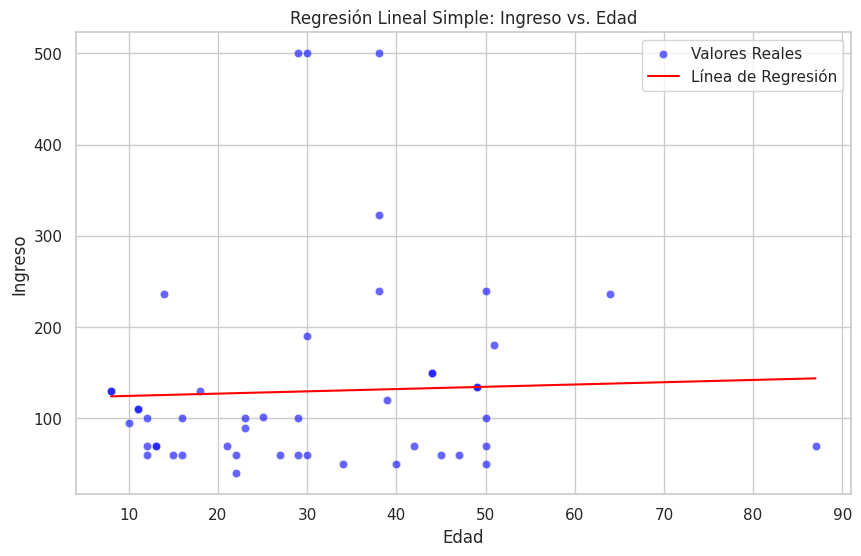

In [37]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Creando Modelo de Regresión Lineal Simple (Ingreso vs. Edad) ---")

# 1. Realizar el merge para combinar df_fact_facturacion y dim_paciente
# Aseguramos que dim_paciente y df_fact_facturacion estén disponibles
if 'df_fact_facturacion' in locals() and 'dim_paciente' in locals():
    df_merged = pd.merge(df_fact_facturacion, dim_paciente, on='id_paciente_sk', how='left')

    # 2. Manejar valores nulos en 'edad'
    # Para la regresión lineal, es importante que no haya nulos en las variables X o y.
    # Imputaremos los valores nulos de 'edad' con la mediana, como se hizo en modelos anteriores.
    df_merged['edad'] = df_merged['edad'].fillna(df_merged['edad'].median())

    # 3. Definir la variable independiente (X) y la variable dependiente (y)
    X_edad = df_merged[['edad']]
    y_ingreso = df_merged['ingreso']

    # Eliminar filas con NaN de X y y de forma consistente si aún quedaran
    # aunque fillna() debería haber resuelto los de 'edad'.
    data_for_lr = pd.DataFrame({
        'edad': X_edad['edad'],
        'ingreso': y_ingreso
    })
    data_for_lr.dropna(inplace=True)

    X_edad = data_for_lr[['edad']]
    y_ingreso = data_for_lr['ingreso']

    # 4. Dividir los datos en conjuntos de entrenamiento y prueba
    X_train_edad, X_test_edad, y_train_ingreso, y_test_ingreso = train_test_split(X_edad, y_ingreso, test_size=0.2, random_state=42)

    # 5. Inicializar y entrenar el modelo de regresión lineal
    model_edad = LinearRegression()
    model_edad.fit(X_train_edad, y_train_ingreso)

    # 6. Realizar predicciones en el conjunto de prueba
    y_pred_edad = model_edad.predict(X_test_edad)

    # --- Evaluación del Modelo de Regresión Lineal Simple ---
    print("\n--- Métricas del Modelo de Regresión Lineal Simple (Ingreso vs. Edad) ---")

    r2_edad = r2_score(y_test_ingreso, y_pred_edad)
    mae_edad = mean_absolute_error(y_test_ingreso, y_pred_edad)
    mse_edad = mean_squared_error(y_test_ingreso, y_pred_edad)
    rmse_edad = np.sqrt(mse_edad)

    print(f"Coeficiente (edad): {model_edad.coef_[0]:.4f}")
    print(f"Intercepto: {model_edad.intercept_:.4f}")
    print(f"R-cuadrado (R2): {r2_edad:.4f}")
    print(f"Error Absoluto Medio (MAE): {mae_edad:.4f}")
    print(f"Error Cuadrático Medio (MSE): {mse_edad:.4f}")
    print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_edad:.4f}")

    print("\nInterpretación:")
    print(f"El coeficiente de {model_edad.coef_[0]:.4f} para 'edad' sugiere que por cada año adicional de edad, el 'ingreso' se ajusta en esa cantidad.")
    print(f"Un R-cuadrado de {r2_edad:.4f} indica que el {r2_edad*100:.2f}% de la variabilidad en el 'ingreso' puede ser explicado por la 'edad' en este modelo simple. Un valor bajo de R2 sugiere que la edad por sí sola no es un fuerte predictor del ingreso.")

    # --- Visualización del Modelo de Regresión Lineal Simple ---
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_test_edad['edad'], y=y_test_ingreso, label='Valores Reales', color='blue', alpha=0.6)
    sns.lineplot(x=X_test_edad['edad'], y=y_pred_edad, color='red', label='Línea de Regresión')
    plt.title('Regresión Lineal Simple: Ingreso vs. Edad')
    plt.xlabel('Edad')
    plt.ylabel('Ingreso')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Error: El DataFrame 'df_fact_facturacion' o 'dim_paciente' no se encontró. Asegúrate de haber cargado las tablas previamente.")

--                  FIN                   --